# package_LAB

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_LAB
import package_DBR
from package_DBR import SelectPath_RT
from package_LAB import LL_RT, PID_RT, IMC_Tuning, Margin

# LL_RT()

In [46]:
help(LL_RT)

Help on function LL_RT in module package_LAB:

LL_RT(MV, Kp, Tlead, Tlag, Ts, PV, PVInit=0, method='EBD')
    The function "LL_RT" needs to be included in a "for or while loop".

    :MV: MV (or Manipulated Value / Input) vector
    :Kp: process gain
    :Tlead: lead time constant [s]
    :Tlag: lag time constant [s]
    :Ts: sampling period [s]

    :PV: PV (or Process Value / Output) vector

    :PVInit: Initial value for PV (optional: default value is 0): used if LL_RT is ran first in the sequence and no value of PV is available yet.

    :method: discretisation method (optional: default value is 'EBD')
        EBD: Euler Backward Difference
        EFD: Euler Forward Difference

    The function "LL_RT" appends new values to the vector "PV".
    The appended values are based on the Lead-Lag transfer function:
    P(s) = Kp * (Tlead*s + 1) / (Tlag*s + 1)



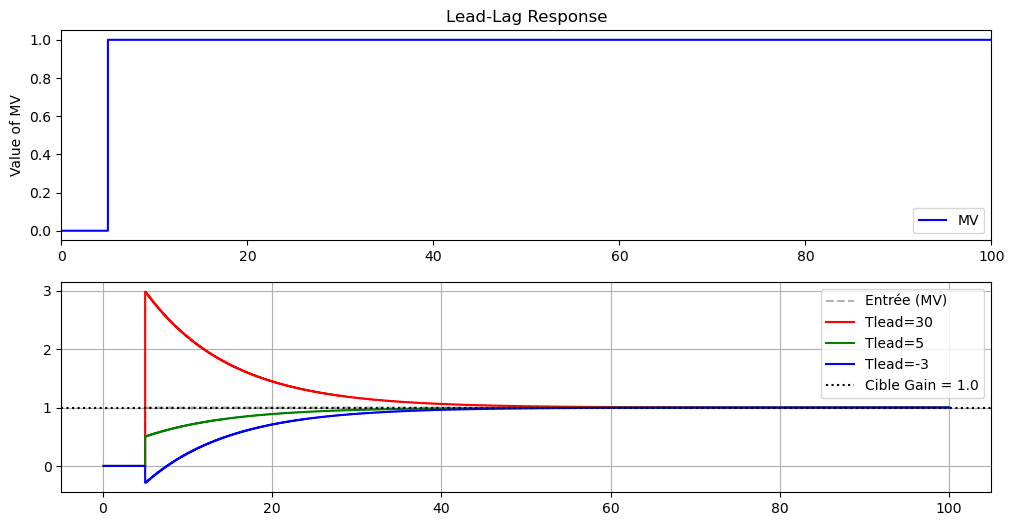

In [47]:
import numpy as np
import matplotlib.pyplot as plt


TSim = 100
Ts = 0.1 
N = int(TSim/Ts) + 1
t = []
MV = [] 
PV_lead = []; PV_lead2 = []; PV_lead3 = [] 

MVPath = {0: 0, 5: 1, TSim: 1}
Tlag_fixe = 10.0
Kp = 1.0


for i in range(1, N):
    t.append(i * Ts)
    SelectPath_RT(MVPath, t, MV)
    
    LL_RT(MV, Kp, 30.0, Tlag_fixe, Ts, PV_lead, method='EBD')
    LL_RT(MV, Kp, 5.0,  Tlag_fixe, Ts, PV_lead2, method='EBD')
    LL_RT(MV, Kp, -3.0, Tlag_fixe, Ts, PV_lead3, method='EBD')

plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')

plt.ylabel('Value of MV')
plt.title('Lead-Lag Response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t, MV, 'k--', label='Entrée (MV)', where='post', alpha=0.3)
plt.step(t, PV_lead, 'r-', label='Tlead=30 ', where='post')
plt.step(t, PV_lead2, 'g-', label='Tlead=5 ', where='post')
plt.step(t, PV_lead3, 'b-', label='Tlead=-3 ', where='post')
plt.axhline(y=Kp, color='k', linestyle=':', label='Cible Gain = 1.0')
plt.legend(); plt.grid(True); plt.show()

# IMC_Tuning

In [48]:
help(IMC_Tuning)

Help on function IMC_Tuning in module package_LAB:

IMC_Tuning(Kp, T1, theta, T2=0, tauc=None, model='FOPDT')
    The function "IMC_Tuning" calculates the PID controller parameters (Kc, Ti, Td)
    based on the Internal Model Control (IMC) rules.

    :Kp: process gain
    :T1: dominant time constant [s] (Tp1)
    :theta: process dead time [s] (thetap)
    :T2: second time constant [s] (Tp2) - (optional: default value is 0)
    :tauc: desired closed-loop time constant [s] (optional: default calculation provided)

    :model: type of process model used for tuning (optional: default is 'FOPDT')
        'FOPDT': First Order Plus Dead Time
        'SOPDT': Second Order Plus Dead Time

    :return:
        Kc: controller gain
        Ti: integral time constant [s]
        Td: derivative time constant [s]

    The function uses the simplified IMC rules (Skogestad) where:
    - For FOPDT: P(s) = Kp * exp(-theta*s) / (T1*s + 1)
    - For SOPDT: P(s) = Kp * exp(-theta*s) / ((T1*s + 1)*(T2*s + 1

In [49]:
Kp = 0.36
Tp1 = 170.82
Tp2 = 26.55
thetap = 13.31

Lambda = 0.9

Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2= Tp2, tauc=Lambda*Tp1 , model='SOPDT')

print(f"PID Tuning : Kc={Kc:.2f}, Ti={Ti:.2f}, Td={Td:.2f}")

PID Tuning : Kc=3.28, Ti=197.37, Td=22.98


# PID_RT()

In [50]:
help(PID_RT)

Help on function PID_RT in module package_LAB:

PID_RT(
    SP,
    PV,
    Man,
    MVMan,
    MVFF,
    Kc,
    Ti,
    Td,
    alpha,
    Ts,
    MVMin,
    MVMax,
    MV,
    MVP,
    MVI,
    MVD,
    E,
    ManFF=False,
    PVInit=0,
    method='EBD'
)
    The function "PID_RT" needs to be included in a "for or while loop".

    :SP: SP (or SetPoint) vector
    :PV: PV (or Process Value) vector
    :Man: Man (or Manual controller mode) vector (True or False)
    :MVMan: MVMan (or Manual value for MV) vector
    :MVFF: MVFF (or Feedforward) vector

    :Kc: controller gain
    :Ti: integral time constant [s]
    :Td: derivative time constant [s]
    :alpha: Tfd = alpha*Td where Tfd is the derivative filter time constant [s]
    :Ts: sampling period [s]

    :MVMin: minimum value for MV (used for saturation and anti wind-up)
    :MVMax: maximum value for MV (used for saturation and anti wind-up)

    :MV: MV (or Manipulated Value) vector
    :MVP: MVP (or Propotional part of MV) ve

In [51]:
Kp = 0.36
Tp1 = 170.82
Tp2 = 26.55
thetap = 13.31

Kd = 0.31
Td1 = 161.20
Td2 = 32.3
thetad = 15.75

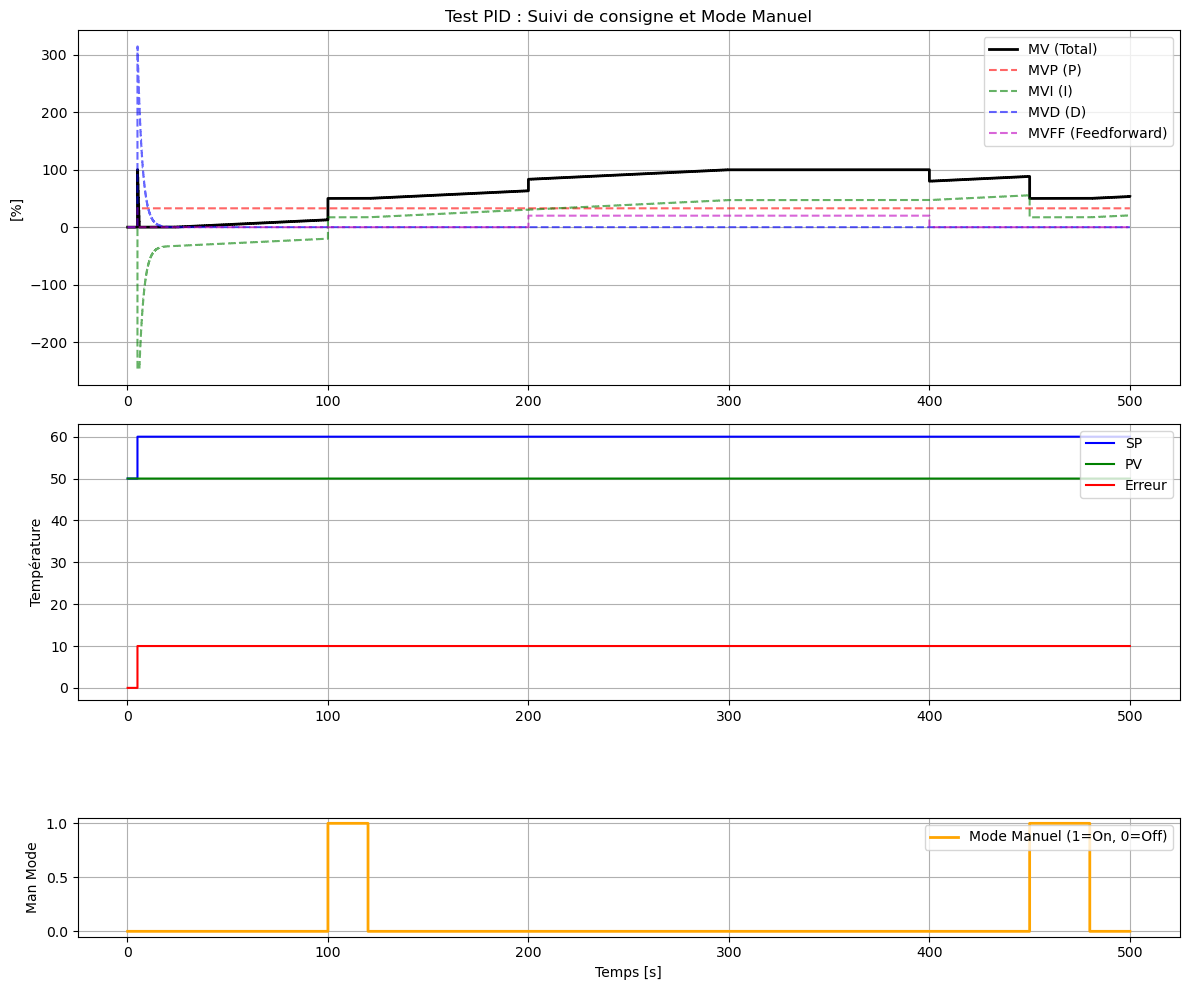

PID Tuning : Kc=3.28, Ti=197.37, Td=22.98
Dernières valeurs : P=32.82, I=20.52, D=0.00, FF=0.00


In [ ]:
TSim = 500
Ts = 0.1 
N = int(TSim/Ts) + 1

t = []
E = []
SP = []
PV = []
Man = []
MVMan = []
MVFF = []
MV = []
MVP = [] 
MVI = [] 
MVD = []


SPPath = {0: 50, 5: 60, TSim: 60}
PVPath = {0: 50, TSim: 50}
ManPath = {0: False, 100: True, 120: False, 450: True,  480: False, TSim: False}
MVManPath = {0: 50, TSim: 50}
MVFFPath = {0: 0, 200: 20, 400:0, TSim: 0}

alpha = 0.9
Lambda = 0.9
Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2= Tp2, tauc=Lambda*Tp1 , model='SOPDT')
MVMin = 0
MVMax = 100

for i in range(1, N):
    t.append(i * Ts)
    
    SelectPath_RT(SPPath, t, SP)
    SelectPath_RT(PVPath, t, PV)
    SelectPath_RT(ManPath, t, Man)
    SelectPath_RT(MVManPath, t, MVMan)
    SelectPath_RT(MVFFPath, t, MVFF)
    
    
    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E)



plt.figure(figsize=(12, 10))

#MV 
ax1 = plt.subplot2grid((12, 1), (0, 0), rowspan=5)
ax1.step(t, MV, 'k-', lw=2, label='MV (Total)', where='post')
ax1.step(t, MVP, 'r--', label='MVP (P)', where='post', alpha=0.6)
ax1.step(t, MVI, 'g--', label='MVI (I)', where='post', alpha=0.6)
ax1.step(t, MVD, 'b--', label='MVD (D)', where='post', alpha=0.6)
ax1.step(t, MVFF, 'm--', label='MVFF (Feedforward)', where='post', alpha=0.6)
ax1.set_ylabel('[%]')
ax1.set_title('Test PID : Suivi de consigne et Mode Manuel')
ax1.legend(loc='upper right')
ax1.grid(True)

#SP, PV et E 
ax2 = plt.subplot2grid((12, 1), (5, 0), rowspan=4)
ax2.step(t, SP, 'b-', label='SP', where='post')
ax2.step(t, PV, 'g-', label='PV', where='post')
ax2.step(t, E, 'r-', label='Erreur', where='post')
ax2.set_ylabel('Température')
ax2.legend(loc='upper right')
ax2.grid(True)

#Mode Manuel 
ax3 = plt.subplot2grid((12, 1), (10, 0), rowspan=2)
ax3.step(t, [int(m) for m in Man], 'orange', lw=2, label='Mode Manuel (1=On, 0=Off)', where='post')
ax3.set_ylabel('Man Mode')
ax3.set_xlabel('Temps [s]')
ax3.legend(loc='upper right')
ax3.grid(True)

plt.tight_layout()
plt.show()
print(f"PID Tuning : Kc={Kc:.2f}, Ti={Ti:.2f}, Td={Td:.2f}")
print(f"Dernières valeurs : P={MVP[-1]:.2f}, I={MVI[-1]:.2f}, D={MVD[-1]:.2f}, FF={MVFF[-1]:.2f}")

# Margin

In [53]:
help(Margin)

Help on function Margin in module package_LAB:

Margin(Kp, Tp1, Tp2, thetap, Kc, Ti, Td, alpha, omega)
    The function "Margin" calculates the stability margins of the closed-loop system
    based on the frequency response of the Open-Loop transfer function L(s) = C(s) * P(s).

    :Kp: process gain
    :Tp1: process dominant time constant [s]
    :Tp2: process second time constant [s]
    :thetap: process dead time (delay) [s]

    :Kc: controller gain
    :Ti: integral time constant [s]
    :Td: derivative time constant [s]
    :alpha: derivative filter factor

    :omega: frequency vector [rad/s] (usually created with np.logspace)

    :return:
        GM: Gain Margin (linear scale)
        PM: Phase Margin [degrees]
        wc: Crossover frequency [rad/s] (frequency where gain = 1 or 0 dB)
        w180: Ultimate frequency [rad/s] (frequency where phase = -180°)

    The Gain Margin (GM) indicates how much the controller gain can be increased before
    the system becomes unstable.

In [54]:
omega = np.logspace(-4, 1, 1000) # Fréquences de 10^-4 à 10^1 rad/s
GM, PM, wc, w180 = Margin(Kp, Tp1, Tp2, thetap, Kc, Ti, Td, alpha, omega)

print(f"Marge de Gain : {GM:.2f} ({20*np.log10(GM):.2f} dB) à {w180:.3f} rad/s")
print(f"Marge de Phase : {PM:.2f}° à {wc:.3f} rad/s")

Marge de Gain : 363.29 (51.21 dB) à 0.975 rad/s
Marge de Phase : 85.49° à 0.006 rad/s


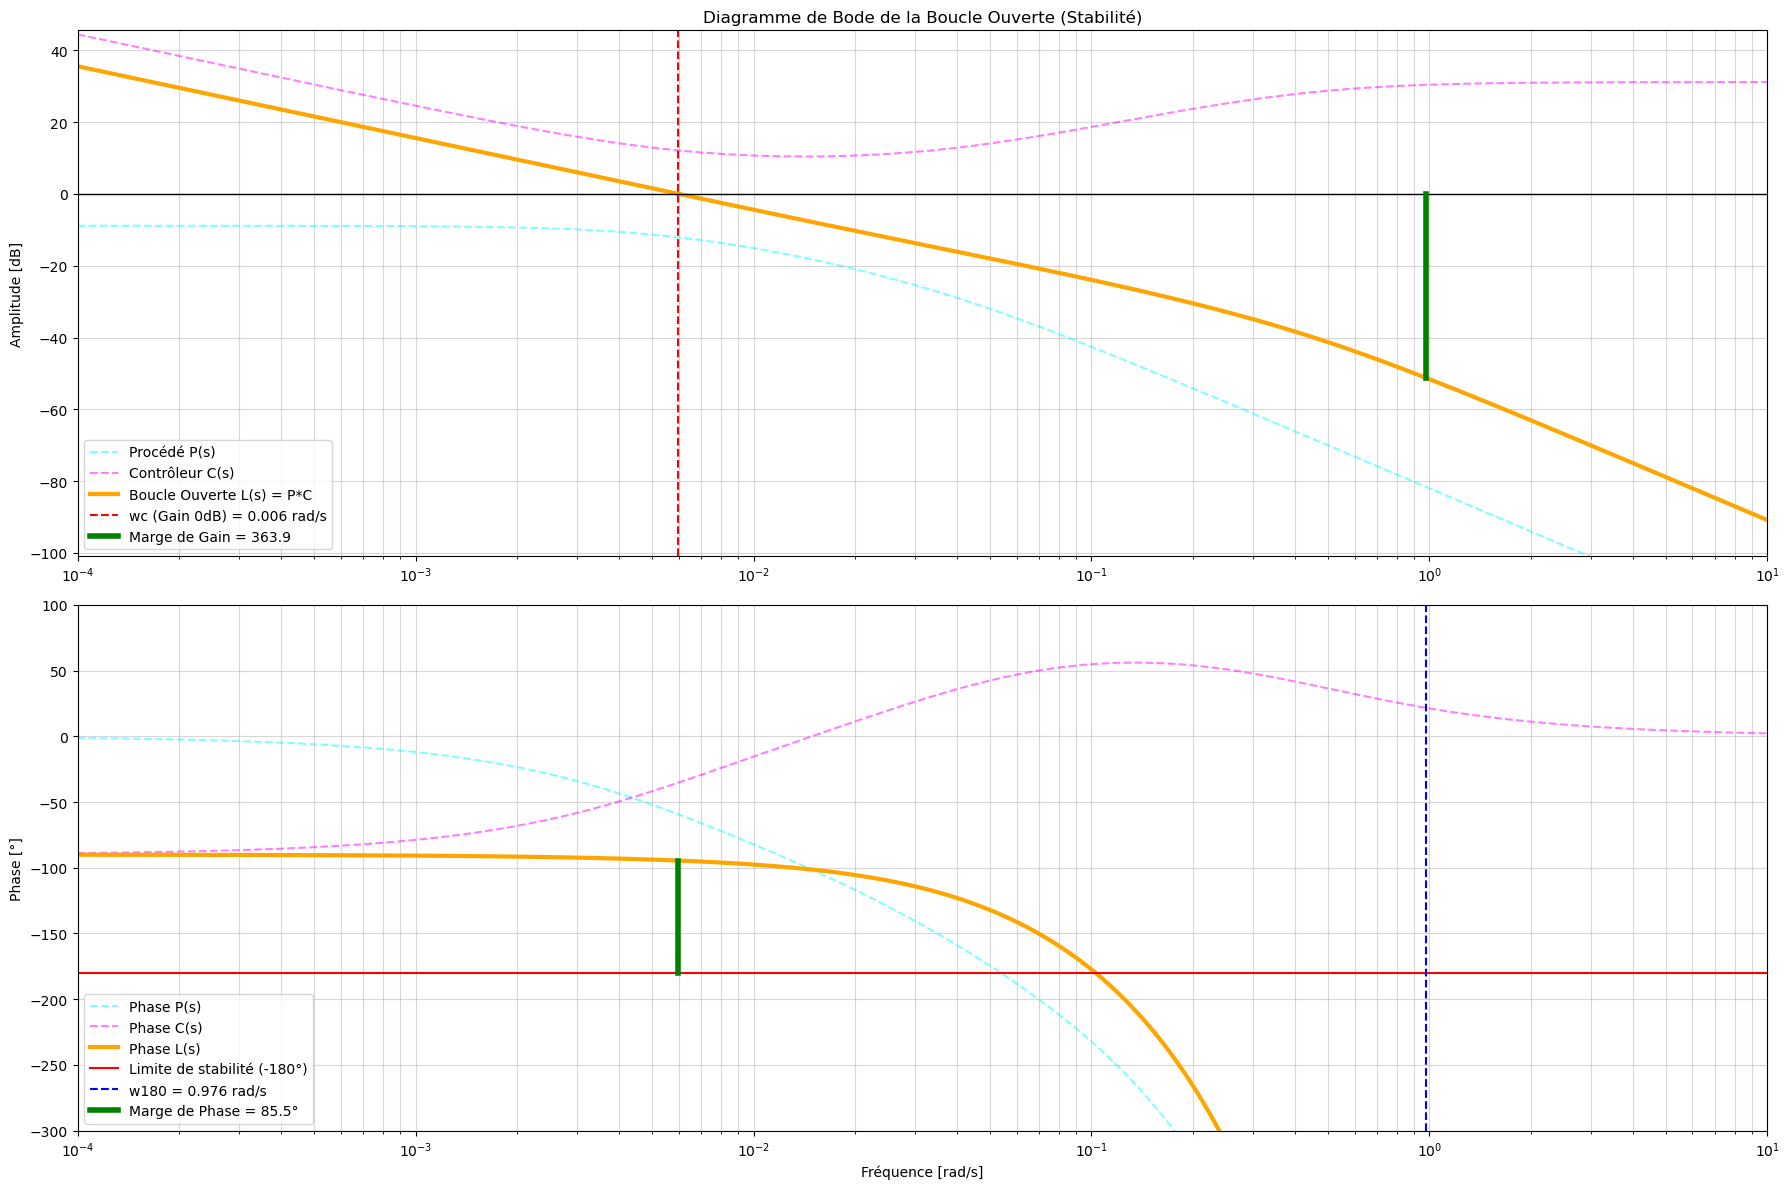

In [55]:
omega = np.logspace(-4, 1, 10000)
s = 1j * omega

Ps = (Kp * np.exp(-thetap * s)) / ((Tp1 * s + 1) * (Tp2 * s + 1))

Cs = Kc * (1 + 1/(Ti * s) + (Td * s) / (alpha * Td * s + 1))

Ls = Ps * Cs

GM, PM, wc, w180 = Margin(Kp, Tp1, Tp2, thetap, Kc, Ti, Td, alpha, omega)

plt.figure(figsize=(18, 12))

plt.subplot(2, 1, 1)
mag_db = 20 * np.log10(np.abs(Ls))

plt.semilogx(omega, 20*np.log10(np.abs(Ps)), color='cyan', linestyle='--', alpha=0.5, label='Procédé P(s)')
plt.semilogx(omega, 20 * np.log10(np.abs(Cs)), color = 'magenta', linestyle = '--', alpha = 0.5, label = 'Contrôleur C(s)')

plt.semilogx(omega, mag_db, 'orange', linewidth=3, label='Boucle Ouverte L(s) = P*C')
plt.axhline(0, color='black', linestyle='-', linewidth=1) 
plt.axvline(wc, color='red', linestyle='--', label=f'wc (Gain 0dB) = {wc:.3f} rad/s')

plt.plot([w180, w180], [0, - 20*np.log10(GM)], color='green', linewidth=4, label=f'Marge de Gain = {GM:.1f}')

plt.ylabel('Amplitude [dB]')
plt.title('Diagramme de Bode de la Boucle Ouverte (Stabilité)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='best')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.min(mag_db)-10, np.max(mag_db)+10])

plt.subplot(2, 1, 2)
phase_P = np.rad2deg(np.unwrap(np.angle(Ps)))
phase_C = np.rad2deg(np.unwrap(np.angle(Cs)))
phase_L = np.rad2deg(np.unwrap(np.angle(Ls)))

plt.semilogx(omega, phase_P, color='cyan', linestyle='--', alpha=0.5, label='Phase P(s)')
plt.semilogx(omega, phase_C, color='magenta', linestyle='--', alpha=0.5, label='Phase C(s)')
plt.semilogx(omega, phase_L, color = 'orange', linewidth = 3, label = 'Phase L(s)')

plt.axhline(-180, color='red', linestyle='-', linewidth=1.5, label='Limite de stabilité (-180°)')
plt.axvline(w180, color='blue', linestyle='--', label=f'w180 = {w180:.3f} rad/s')

plt.plot([wc, wc], [-180, -180 + PM], color='green', linewidth=4, label=f'Marge de Phase = {PM:.1f}°')

plt.ylabel('Phase [°]')
plt.xlabel('Fréquence [rad/s]')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='best')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([max(min(phase_L)-20, -300), 100])

plt.tight_layout()
plt.show()